In [ ]:
!pip install torchvision==0.15.0
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import numpy as np
import cv2
import nibabel as nib
import matplotlib.pyplot as plt
import glob
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import random

  Using cached torchvision-0.15.0-cp311-cp311-manylinux1_x86_64.whl.metadata (11 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement torch==2.0.0+cu117 (from torchvision) (from versions: 1.13.0, 1.13.1, 2.0.0, 2.0.1, 2.1.0, 2.1.1, 2.1.2, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0)
ERROR: No matching distribution found for torch==2.0.0+cu117


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get update -y && apt-get install -y fuse lsb-release; \
    curl -L -O https://github.com/GoogleCloudPlatform/gcsfuse/releases/download/v0.41.12/gcsfuse_0.41.12_amd64.deb; \
    dpkg --install gcsfuse_0.41.12_amd64.deb; \
    apt-get update; \
    apt-get clean;

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Fetched 257 kB in 2s (135 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package list

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
project_id = 'sfsu-378805'
bucket_name = 'csc-509-image-files'
!gcloud config set project {project_id}

Are you sure you wish to set property [core/project] to sfsu-378805?

Do you want to continue (Y/n)?  y

Updated property [core/project].


In [ ]:
!gsutil ls

You are attempting to access protected data with no configured
credentials. Please visit https://cloud.google.com/console#/project
and sign up for an account, and then run the "gcloud auth login"
command to configure gsutil to use these credentials.


In [ ]:
!mkdir images

mkdir: cannot create directory ‘images’: File exists


In [ ]:
!gcsfuse --implicit-dirs csc-509-image-files images

2025/04/27 04:36:00.355448 Start gcsfuse/0.41.12 (Go version go1.18.4) for app "" using mount point: /content/images
2025/04/27 04:36:00.367724 Opening GCS connection...
2025/04/27 04:36:01.617572 Mounting file system "csc-509-image-files"...
2025/04/27 04:36:01.618560 File system has been successfully mounted.


In [ ]:
!ls images/

Archive				Module1_ADNI	       Module2_ADNI
Module0_DataCuration		Module1_BraTS	       Module2_ADNI_New
Module0_MRI_PET_Classification	Module1_BraTS.tar.bz2
Module0_UPENNGBM		Module1_PET


In [ ]:
!ls images/Module1_BraTS/

MICCAI_BraTS2020_TrainingData	 MRI_test_label.npy    MRI_val_images.npy
MICCAI_BraTS2020_ValidationData  MRI_train_images.npy  MRI_val_label.npy
MRI_test_images.npy		 MRI_train_label.npy


In [ ]:
# Let's define the train data path.
TRAIN_DATA_PATH = Path('/content/images/Module1_BraTS/MICCAI_BraTS2020_TrainingData')

# BraTS also has "ValidationData" which has only images and no segmentation masks.
VAL_DATA_PATH = Path('/content/images/Module1_BraTS/MICCAI_BraTS2020_ValidationData')

In [ ]:
# Let's create the training, validation and test ids.

train_dir = [f.path for f in os.scandir(TRAIN_DATA_PATH) if f.is_dir()]

def list_to_ids(dir:str):
    """
    Will convert the dir paths to ids by parsing the paths.
    dir: string, image dir paths in BRATS
    """
    x = []
    for i in range(0,len(dir)):
        x.append(dir[i].split('/')[-1])
    return x

ids = list_to_ids(train_dir)

# Split dataset to create training ids, validation ids and test ids
# Here we have selected the size of test set as 20% which is a common practice.
train_ids, test_ids = train_test_split(ids,test_size=0.2)

# Create validation ids by further splitting the train ids, we again use 20% as size of validation set.
# Validation set is also referred to as tuning set.

train_ids, val_ids = train_test_split(train_ids,test_size=0.2)

In [ ]:
# Now looks at the number of patient ids in training, validation and test sets
print(f'There are {len(train_ids)} patient ids in training set')
print(f'There are {len(val_ids)} patient ids in validation set')
print(f'There are {len(test_ids)} patient ids in test set')

There are 236 patient ids in training set
There are 59 patient ids in validation set
There are 74 patient ids in test set


In [ ]:
# Next we can reduce this for testing purposes
train_ids = train_ids[:100]
val_ids = val_ids[:25]
test_ids = test_ids[:20]

In [ ]:
# The type of images available: T1, T1CE, T2, FLAIR and corresponding masks

# We will use the read_patient_niftis module we had learnt in the previous notebook
def read_patient_niftis(patient_id: str,
                        niftis_to_load = ['t1', 't1ce', 't2', 'flair', 'seg'],
                        data_path = TRAIN_DATA_PATH):
    """
    Will read in the images from a single patient and return a dictionary of
    those images with the key as the image type and the value as the nifti object.
    patient_id: string of format '001' through '369', patient ID in BRATS
    niftis_to_load: default is list containing all the types of images that we care about; can sub in another list if desired.
    data_path: default is DATA_PATH specified above with respect to the mounted google drive (in colab)

    """
    patient_image_dict = {}
    for image in niftis_to_load:
        patient_image_dict[image]=nib.load(Path(data_path, f'{patient_id}', f'{patient_id}_{image}.nii.gz'))
    return patient_image_dict


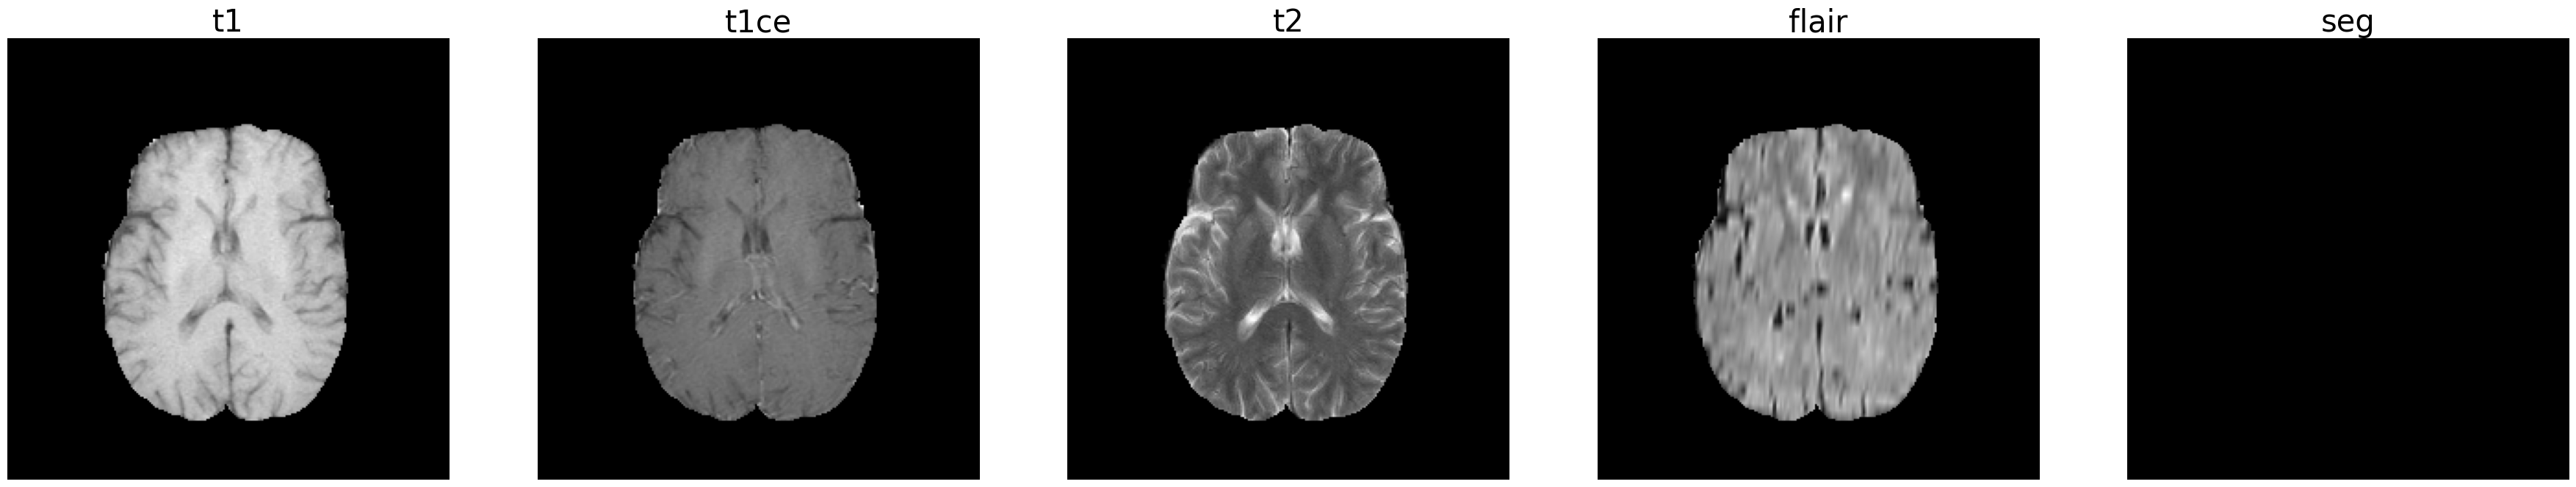

In [ ]:
# Let's look at one of the image and the corresponding segmentation mask from the training set before we proceed
pt_img_dict = read_patient_niftis(train_ids[12])
# Now lets visualize all the images side by side to get a sense of what's happening.
plt.figure(figsize=(45,30)) # specifying the overall grid size
for i, (key, value) in enumerate(pt_img_dict.items()):
    plt.subplot(1, 5, i+1)
    # Get the middle slice of the volume and transpose the image so that its facing upward.
    plt.imshow(value._dataobj[:, :, value.shape[-1]//2].T, cmap='gray')
    plt.axis('off')
    plt.title(key, fontsize=30)
plt.show()

In [ ]:
def normalize(input_image, input_mask, percentile=0.001, eps=1e-6, device=None):
    """
    Normalize the input image between 0 and 1 using percentile scaling.
    Keeps the input_mask as-is for multi-class segmentation.

    Parameters:
    - input_image (ndarray or tensor): The image to normalize
    - input_mask (ndarray or tensor): The multi-class mask to return unmodified
    - percentile (float): Percentile cutoff for intensity normalization
    - eps (float): Small constant to avoid division by zero
    - device (torch.device or None): Optional, move tensors to GPU/CPU device

    Returns:
    - img_normalized (FloatTensor): Normalized image [0,1]
    - input_mask (LongTensor): Original multi-class mask
    """
    # Convert image to float tensor
    if not isinstance(input_image, torch.Tensor):
        input_image = torch.tensor(input_image, dtype=torch.float32)
    if device:
        input_image = input_image.to(device)

    # Flatten and compute robust percentile bounds
    img_flat = input_image.contiguous().view(-1)
    min_val = torch.quantile(img_flat, percentile)
    max_val = torch.quantile(img_flat, 1 - percentile)

    # Normalize using min/max from percentiles
    img_normalized = (input_image - min_val) / (max_val - min_val + eps)
    img_normalized = torch.clamp(img_normalized, 0.0, 1.0)

    # Ensure float32 type
    img_normalized = img_normalized.float()

    # Convert mask to long tensor (needed for PyTorch CrossEntropyLoss)
    if not isinstance(input_mask, torch.Tensor):
        input_mask = torch.tensor(input_mask, dtype=torch.int64)
    else:
        input_mask = input_mask.long()
    if device:
        input_mask = input_mask.to(device)

    return img_normalized, input_mask

In [ ]:
# Example usage
# Assuming pt_img_dict['t2'] and pt_img_dict['seg'] are loaded as PyTorch tensors
t2_img = torch.tensor(pt_img_dict['t2'].get_fdata(), dtype=torch.float32)
seg_img = torch.tensor(pt_img_dict['seg'].get_fdata(), dtype=torch.int64)

img_normalized, mask_normalized = normalize(t2_img, seg_img)

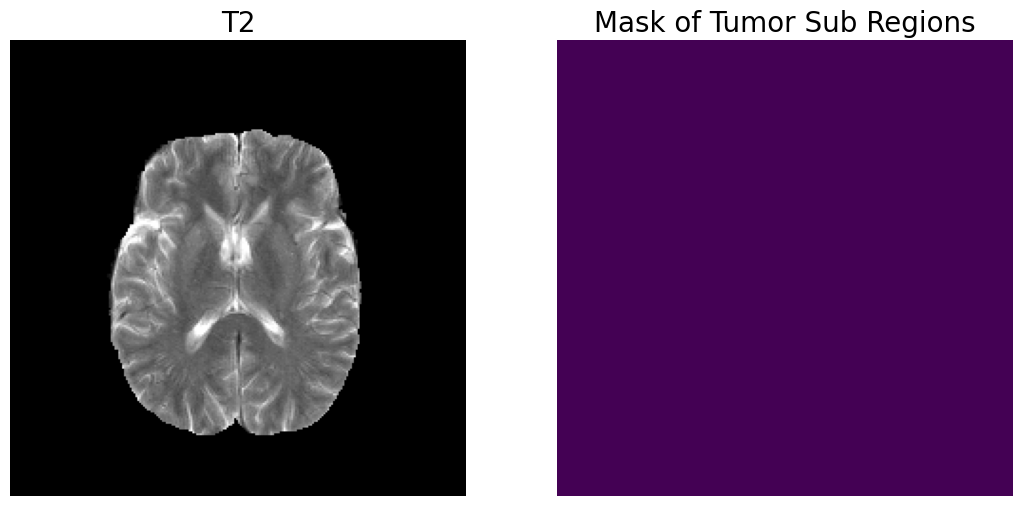

In [ ]:
# Convert PyTorch tensors to NumPy arrays for plotting
img_np = img_normalized.cpu().numpy()
mask_np = mask_normalized.cpu().numpy()

# Get center slice
center_slice = img_np.shape[2] // 2

# Visualize the images
plt.figure(figsize=(20, 30))

# Original T2 image
plt.subplot(1, 3, 1)
plt.imshow(img_np[:, :, center_slice].T, cmap='gray')  # Assuming the third dimension is the slice axis
plt.axis('off')
plt.title('T2', fontsize=20)

# Original segmentation mask
plt.subplot(1, 3, 2)
plt.imshow(seg_img[:, :, center_slice].T)
plt.axis('off')
plt.title('Mask of Tumor Sub Regions', fontsize=20)

plt.show()

In [ ]:
# Evaluation metrics to be used to measure performance
!pip install medpy
from sklearn.metrics import precision_score, recall_score, f1_score
from medpy.metric.binary import hd95

# Example usage
# Assuming your outputs are shape (B, C, H, W) with logits or softmax probabilities
# y_pred = torch.argmax(output_logits, dim=1)  # shape: (B, H, W)
# y_true = ground_truth_masks                  # shape: (B, H, W)

# results = evaluate_segmentation(y_true, y_pred, num_classes=4)

# for k, v in results.items():
#     if isinstance(v, list):
#         print(f"{k}: {[round(score, 4) for score in v]}")
#     else:
#         print(f"{k}: {round(v, 4)}")

def flatten_tensor(y):
    """
    Flattens a tensor to 1D and converts to float32.
    """
    return y.contiguous().view(-1).float()

def dice_score_per_class(y_true, y_pred, num_classes, smooth=1e-6):
    """
    Computes Dice score for each class in a multi-class segmentation.

    Args:
        y_true (LongTensor): Ground truth mask [B, H, W]
        y_pred (LongTensor): Predicted mask [B, H, W]
        num_classes (int): Number of segmentation classes (including background)
        smooth (float): Smoothing term to avoid division by zero

    Returns:
        List of dice scores for each class.
    """
    dice_scores = []
    for c in range(num_classes):
        true_c = (y_true == c).float()
        pred_c = (y_pred == c).float()
        intersection = (true_c * pred_c).sum()
        score = (2. * intersection + smooth) / (true_c.sum() + pred_c.sum() + smooth)
        dice_scores.append(score.item())
    return dice_scores

def iou_score_per_class(y_true, y_pred, num_classes, smooth=1e-6):
    """
    Computes IoU score (Jaccard index) for each class.

    Returns:
        List of IoU scores per class.
    """
    iou_scores = []
    for c in range(num_classes):
        true_c = (y_true == c).float()
        pred_c = (y_pred == c).float()
        intersection = (true_c * pred_c).sum()
        union = true_c.sum() + pred_c.sum() - intersection
        score = (intersection + smooth) / (union + smooth)
        iou_scores.append(score.item())
    return iou_scores

def classification_metrics(y_true, y_pred, average='macro'):
    """
    Computes precision, recall, and F1 score using scikit-learn.
    Expects flat arrays of integer class labels.

    Returns:
        Dict with precision, recall, and f1-score.
    """
    y_true_np = y_true.view(-1).cpu().numpy()
    y_pred_np = y_pred.view(-1).cpu().numpy()
    return {
        'precision': precision_score(y_true_np, y_pred_np, average=average, zero_division=0),
        'recall': recall_score(y_true_np, y_pred_np, average=average, zero_division=0),
        'f1': f1_score(y_true_np, y_pred_np, average=average, zero_division=0)
    }

def hausdorff_score(y_true, y_pred):
    """
    Computes the 95% Hausdorff Distance between binary masks.
    Returns -1 if shape mismatch or empty mask.

    Only works with 2D or 3D arrays, not tensors.
    """
    try:
        return hd95(y_pred.cpu().numpy(), y_true.cpu().numpy())
    except:
        return -1.0

def evaluate_segmentation(y_true, y_pred, num_classes):
    """
    Complete evaluation function combining all metrics.

    Args:
        y_true (Tensor): Ground truth mask [B, H, W]
        y_pred (Tensor): Predicted mask [B, H, W]
        num_classes (int): Number of classes

    Returns:
        Dictionary of evaluation metrics
    """
    metrics = {}
    metrics['dice'] = dice_score_per_class(y_true, y_pred, num_classes)
    metrics['iou'] = iou_score_per_class(y_true, y_pred, num_classes)
    metrics.update(classification_metrics(y_true, y_pred, average='macro'))
    return metrics

In [ ]:
# Loss functions

# Fast, standard, works well with softmax output.
class CrossEntropyLoss2d(nn.Module):
    """
    Standard cross-entropy loss for multiclass segmentation.
    Assumes y_pred are raw logits [B, C, H, W] and y_true are class labels [B, H, W].
    """
    def __init__(self, weight=None):
        super(CrossEntropyLoss2d, self).__init__()
        self.loss = nn.CrossEntropyLoss(weight=weight)

    def forward(self, y_pred, y_true):
        return self.loss(y_pred, y_true)

# More sensitive to class imbalance; widely used in BraTS challenges
class DiceLoss(nn.Module):
    """
    Multi-class Dice Loss implementation.
    Computes soft Dice for each class and averages over all.

    Assumes y_pred is softmax or probabilities [B, C, H, W] and y_true is [B, H, W]
    """
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        num_classes = y_pred.shape[1]

        # One-hot encode the ground truth
        y_true_one_hot = F.one_hot(y_true, num_classes).permute(0, 3, 1, 2).float()

        y_pred = F.softmax(y_pred, dim=1)

        dice = 0
        for c in range(num_classes):
            pred_flat = y_pred[:, c].contiguous().view(-1)
            true_flat = y_true_one_hot[:, c].contiguous().view(-1)
            intersection = (pred_flat * true_flat).sum()
            dice += (2. * intersection + self.smooth) / (pred_flat.sum() + true_flat.sum() + self.smooth)

        return 1 - dice / num_classes

# Penalizes over-segmentation and under-segmentation; complementary to Dice
class JaccardLoss(nn.Module):
    """
    Multi-class Jaccard loss, also called IoU loss.
    """
    def __init__(self, smooth=1e-6):
        super(JaccardLoss, self).__init__()
        self.smooth = smooth

    def forward(self, y_pred, y_true):
        num_classes = y_pred.shape[1]
        y_true_one_hot = F.one_hot(y_true, num_classes).permute(0, 3, 1, 2).float()
        y_pred = F.softmax(y_pred, dim=1)

        iou = 0
        for c in range(num_classes):
            pred_flat = y_pred[:, c].contiguous().view(-1)
            true_flat = y_true_one_hot[:, c].contiguous().view(-1)
            intersection = (pred_flat * true_flat).sum()
            union = pred_flat.sum() + true_flat.sum() - intersection
            iou += (intersection + self.smooth) / (union + self.smooth)

        return 1 - iou / num_classes

# Often leads to better convergence and accuracy than using either loss alone
class ComboLoss(nn.Module):
    """
    Combines Cross-Entropy and Dice Loss for better performance on class imbalance.
    Weigh the contribution of each component with alpha.
    """
    def __init__(self, alpha=0.5):
        super(ComboLoss, self).__init__()
        self.alpha = alpha
        self.cross_entropy = nn.CrossEntropyLoss()
        self.dice = DiceLoss()

    def forward(self, y_pred, y_true):
        ce = self.cross_entropy(y_pred, y_true)
        dice = self.dice(y_pred, y_true)
        return self.alpha * ce + (1 - self.alpha) * dice

# Focal loss is not typically used in BraTS, but it’s useful if
# tumor vs. background pixels are extremely imbalanced
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, y_pred, y_true):
        logpt = -F.cross_entropy(y_pred, y_true, reduction='none')
        pt = torch.exp(logpt)
        focal_loss = -((1 - pt) ** self.gamma) * logpt
        return focal_loss.mean()


In [ ]:
# UNet model architecture
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_classes=4):
        """
        U-Net model for multi-class semantic segmentation.

        Args:
            in_channels (int): Number of input image channels (e.g., 1 for grayscale)
            out_classes (int): Number of output segmentation classes
        """

        # Call the constructor of the parent class (nn.Module)
        super(UNet, self).__init__()

        # --- Encoder (Contracting Path) ---
        # Each block consists of two Conv2D layers with ReLU and BatchNorm

        # Level 1: Input image is processed by two convolutional layers with 64 filters
        # This extracts initial features and reduces spatial dimensions
        self.enc1 = self.conv_block(in_channels, 64)
        # Max pooling with a 2x2 kernel further downsamples the feature maps, reducing spatial resolution by half
        self.pool1 = nn.MaxPool2d(2)

        # Level 2: Features from level 1 are processed with 128 filters, capturing more complex patterns
        # Spatial dimensions are again reduced, leading to a more abstract representation
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Level 3: Features are processed with 256 filters, learning even more complex and abstract representations
        # Spatial resolution is decreased again
        self.enc3 = self.conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Level 4: Features are processed with 512 filters, capturing the most high-level and abstract information
        # This is the deepest level of the encoder, with the lowest spatial resolution
        self.enc4 = self.conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # --- Bottleneck ---
        # This layer processes the most abstract features from the encoder.
        # It uses 1024 filters to capture intricate details and relationships
        # in the downsampled image representation.
        self.bottleneck = self.conv_block(512, 1024)

        # --- Decoder (Expanding Path) ---
        # Each step upsamples and concatenates with encoder feature map (skip connection)

        # Level 4: Upsampling and Feature Processing
        # Upsamples the feature maps from the bottleneck using transposed convolution (increasing spatial dimensions).
        # This effectively doubles the size of the feature maps. The output has 512 channels.
        self.up4 = self.up_block(1024, 512)
        # Processes the upsampled features with two 3x3 convolutions, maintaining 512 output channels.
        # This step uses a skip connection: concatenating the upsampled features with corresponding features
        # from the encoder's Level 4 (enc4) to provide finer details. ReLU and BatchNorm are applied.
        self.dec4 = self.conv_block(1024, 512)

        # Level 3: Upsampling and Feature Processing
        # Further upsamples the features, outputting 256 channels. Spatial resolution is again doubled.
        self.up3 = self.up_block(512, 256)
        # Processes the features (two 3x3 convolutions), keeping 256 channels.
        # Skip connection: concatenates features with the encoder's Level 3 (enc3) features.
        self.dec3 = self.conv_block(512, 256)

        # Level 2: Upsampling and Feature Processing
        # Upsamples the features, outputting 128 channels. Spatial resolution is further doubled.
        self.up2 = self.up_block(256, 128)
        # Processes features, keeping 128 channels.
        # Skip connection from encoder's Level 2 (enc2).
        self.dec2 = self.conv_block(256, 128)

        # Level 1: Upsampling and Feature Processing
        # Final upsampling the features, outputting 64 channels. Spatial resolution is doubled again.
        self.up1 = self.up_block(128, 64)
        # Processes features, keeping 64 channels.
        # Skip connection from encoder's Level 1 (enc1).
        self.dec1 = self.conv_block(128, 64)

        # --- Final Classification Layer ---
        # Outputs raw logits (no softmax/sigmoid); suitable for CrossEntropyLoss
        self.classifier = nn.Conv2d(64, out_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
            """
            Two 3x3 Conv2D layers with BatchNorm and ReLU.
            """
            # Create a sequential container for the layers in the block.
            return nn.Sequential(
                # First 3x3 Convolutional Layer:
                # - Takes 'in_channels' as input and produces 'out_channels' as output.
                # - Uses a 3x3 kernel for spatial filtering.
                # - Applies padding of 1 to preserve spatial dimensions.
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                # ReLU Activation:
                # - Introduces non-linearity to the output of the convolutional layer.
                # - 'inplace=True' saves memory by performing the operation directly on the input tensor.
                nn.ReLU(inplace=True),
                # Batch Normalization:
                # - Normalizes the output of the ReLU activation across the batch dimension.
                # - This helps stabilize training and improve convergence.
                nn.BatchNorm2d(out_channels),
                # Second 3x3 Convolutional Layer:
                # - Takes 'out_channels' as input and produces 'out_channels' as output.
                # - Uses a 3x3 kernel and padding of 1, similar to the first layer.
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                # ReLU Activation:
                # - Applies non-linearity to the output of the second convolutional layer.
                # - 'inplace=True' is used for memory efficiency.
                nn.ReLU(inplace=True),
                # Batch Normalization:
                # - Normalizes the output of the second ReLU activation across the batch dimension.
                nn.BatchNorm2d(out_channels)
            )

    def up_block(self, in_channels, out_channels):
        """
        Transposed convolution for upsampling.
        """
        # Creates a ConvTranspose2d layer for upsampling.
        # - in_channels: Number of input channels.
        # - out_channels: Number of output channels.
        # - kernel_size: Size of the convolutional kernel (2x2 in this case).
        # - stride: Controls the upsampling factor (2 in this case, meaning the spatial dimensions are doubled).
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        # Pass the input 'x' through the first encoder block (enc1) and store the output in 'x1'.
        x1 = self.enc1(x)
        # Pass 'x1' through a max pooling layer (pool1) to downsample it and then through the second encoder block (enc2), storing the result in 'x2'.
        x2 = self.enc2(self.pool1(x1))
        # Similar to above, pass 'x2' through pooling and the third encoder block (enc3), storing in 'x3'.
        x3 = self.enc3(self.pool2(x2))
        # Pass 'x3' through pooling and the fourth encoder block (enc4), storing in 'x4'.
        x4 = self.enc4(self.pool3(x3))

        # Bottleneck
        # Pass 'x4' through pooling and the bottleneck layer, storing the most abstract features in 'x5'.
        x5 = self.bottleneck(self.pool4(x4))

        # Decoder + Skip connections
        # Upsample 'x5' using up_block (up4) and store in 'x'.
        x = self.up4(x5)
        # Concatenate 'x' with features from the encoder's level 4 ('x4') along the channel dimension (dim=1).
        # Then pass this concatenated tensor through the decoder block (dec4) and update 'x'.
        x = self.dec4(torch.cat([x, x4], dim=1))

        # Repeat the upsampling and concatenation process for levels 3, 2, and 1.
        x = self.up3(x)
        x = self.dec3(torch.cat([x, x3], dim=1))

        x = self.up2(x)
        x = self.dec2(torch.cat([x, x2], dim=1))

        x = self.up1(x)
        x = self.dec1(torch.cat([x, x1], dim=1))

        # Final layer (no activation; use CrossEntropyLoss which applies log-softmax)
        # Pass 'x' through the final classification layer (classifier) to get the output.
        return self.classifier(x)


In [ ]:
class BraTSDataset(Dataset):
    def __init__(self, patient_ids, data_path, niftis_to_load=['t1', 't2', 'flair', 'seg'], transform=None):
        """
        Dataset for loading multi-channel BraTS slices with multi-class segmentation masks.

        Args:
            patient_ids (List[str]): List of BraTS patient folder names or IDs
            data_path (Path): Root directory containing BraTS data folders
            niftis_to_load (List[str]): Modalities to load (e.g., ['t1', 't2', 'flair', 'seg'])
            transform (callable, optional): Transform to apply to image slices
        """
        self.patient_ids = patient_ids
        self.data_path = data_path
        self.transform = transform
        self.niftis_to_load = niftis_to_load

    def __len__(self):
        return len(self.patient_ids)

    def find_random_non_empty_slice(self, mask_volume):
        """
        Randomly selects a slice index where the segmentation mask is not empty.
        """
        # Replace all values > 3 with 3.
        mask_volume = torch.clamp(mask_volume, 0, 3)

        non_empty_slices = [i for i in range(mask_volume.shape[2]) if torch.any(mask_volume[:, :, i] != 0)]
        if not non_empty_slices:
            raise ValueError("No non-empty slices found in the mask volume.")
        return random.choice(non_empty_slices)

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]

        # Load all requested modalities for this patient
        pt_img_dict = read_patient_niftis(
            patient_id,
            niftis_to_load=self.niftis_to_load,
            data_path=self.data_path
        )

        # Get the mask first
        seg_img = pt_img_dict['seg'].get_fdata()
        seg_tensor = torch.tensor(seg_img, dtype=torch.int64)

        # Find a non-empty slice in the mask
        slice_idx = self.find_random_non_empty_slice(seg_tensor)

        # Load and normalize each image modality
        channels = []
        for modality in self.niftis_to_load:
            if modality == 'seg':
                continue  # skip the mask
            modality_img = pt_img_dict[modality].get_fdata()
            # Normalize and convert to tensor
            norm_img, _ = normalize(modality_img, seg_img)  # we only use norm_img here
            img_slice = norm_img[:, :, slice_idx]

            # Check for NaN values in the img_slice
            if torch.isnan(img_slice).any():
                print(f"NaN values found in {modality} for patient {patient_id}, slice {slice_idx}")
                # Handle NaN values (e.g., replace with 0, or skip the slice)
                img_slice = torch.nan_to_num(img_slice, nan=0.0) # Example: Replace NaN with 0

            channels.append(img_slice.unsqueeze(0))  # [1, H, W]

        # Stack all modalities into a multi-channel input: [C, H, W]
        img_tensor = torch.cat(channels, dim=0)

        # Select the corresponding slice of the segmentation mask
        mask_slice = seg_tensor[:, :, slice_idx]  # [H, W]

        # Apply optional transform to the image and the mask
        if self.transform:
            img_tensor = self.transform(img_tensor)
            # Resize the mask to match the image size
            resize_transform = transforms.Resize((128, 128), interpolation=InterpolationMode.NEAREST)  # Use nearest for mask
            mask_slice = resize_transform(mask_slice.unsqueeze(0)).squeeze(0)  # Add and remove batch dim
        # Enforce correct number of classes 0-3 and datatype
        mask_slice = torch.clamp(mask_slice, min=0, max=3).long()
        return img_tensor.float(), mask_slice  # [C, H, W], [H, W]

In [ ]:
# For use on training set
train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalizes to [-1, 1] for single channel
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Scales to [-1, 1] for grayscale
])

# MRI intensities are typically pre-normalized using percentile-based min-max scaling
# (as in your normalize() function), but this step ensures consistency for network inputs
# similar to how pretrained models are conditioned.
# If you want to use real dataset statistics replace [0.5] with
# the computed mean/std of your training set.

In [ ]:
train_dataset = BraTSDataset(
    train_ids,
    TRAIN_DATA_PATH,
    niftis_to_load = ['t1', 't2', 'flair', 'seg'],
    transform=train_transform  # includes resizing + optional augmentation
)

val_dataset = BraTSDataset(
    val_ids,
    TRAIN_DATA_PATH,
    niftis_to_load = ['t1', 't2', 'flair', 'seg'],
    transform=val_transform  # resizing and normalization only
)

test_dataset = BraTSDataset(
    test_ids,
    TRAIN_DATA_PATH,
    niftis_to_load = ['t1', 't2', 'flair', 'seg'],
    transform=val_transform
)


In [ ]:
# confirm dataset integrity before training
img, mask = train_dataset[0]
print("Image shape:", img.shape)     # Should be [C, H, W]
print("Mask shape:", mask.shape)     # Should be [H, W]
print("Unique mask labels:", torch.unique(mask))  # e.g., tensor([0, 1, 2, 3])

Image shape: torch.Size([3, 128, 128])
Mask shape: torch.Size([128, 128])
Unique mask labels: tensor([0, 2, 3])


In [ ]:
# Create DataLoaders with standard batch size and performance optimizations
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,          # Shuffle for training
    num_workers=4,
    pin_memory=True        # Improve transfer speed to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,         # No shuffle for validation
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,         # No shuffle for testing
    num_workers=4,
    pin_memory=True
)


In [ ]:
# Confirm dataset sizes (each returns 2D slices)
print(f" Training set: {len(train_dataset)} slices")
print(f" Validation set: {len(val_dataset)} slices")
print(f" Test set: {len(test_dataset)} slices")

# Check one sample shape
sample_img, sample_mask = train_dataset[0]
print(f"Sample input shape: {sample_img.shape} (C, H, W)")
print(f"Sample mask shape: {sample_mask.shape} (H, W)")


 Training set: 100 slices
 Validation set: 25 slices
 Test set: 20 slices
Sample input shape: torch.Size([3, 128, 128]) (C, H, W)
Sample mask shape: torch.Size([128, 128]) (H, W)


In [ ]:
from tqdm import tqdm

def train_model(
    model, train_loader, val_loader, num_epochs=10, learning_rate=0.001, use_gpu=True, num_classes=4,
    early_stopping_patience=5):
    """
    Train a U-Net model on multi-class segmentation data.

    Args:
        model (nn.Module): U-Net segmentation model
        train_loader (DataLoader): DataLoader for training data
        val_loader (DataLoader): DataLoader for validation data
        num_epochs (int): Number of training epochs
        learning_rate (float): Learning rate for optimizer
        use_gpu (bool): Whether to use GPU if available
        num_classes (int): Number of segmentation classes

    Returns:
        metrics_df (pd.DataFrame): DataFrame containing loss values per epoch
    """
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)

    metrics = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'dice_class_0': [],
        'dice_class_1': [],
        'dice_class_2': [],
        'dice_class_3': []
    }

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f'Training Epoch {epoch+1}/{num_epochs}', leave=False):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            # Add gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_truth = []

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validating', leave=False):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds)
                all_truth.append(masks)

        val_loss /= len(val_loader)

        # Combine predictions
        y_pred = torch.cat(all_preds)
        y_true = torch.cat(all_truth)

        # Per-class Dice scores
        dice_scores = []
        for cls in range(num_classes):
            pred_cls = (y_pred == cls).float()
            true_cls = (y_true == cls).float()
            intersection = (pred_cls * true_cls).sum().item()
            union = pred_cls.sum().item() + true_cls.sum().item()
            dice = (2. * intersection) / (union + 1e-6)
            dice_scores.append(dice)

        # Log metrics
        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        for i in range(num_classes):
            metrics[f'dice_class_{i}'].append(dice_scores[i])

        print(f"[Epoch {epoch+1}] Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Dice: {[round(d, 4) for d in dice_scores]}")

        scheduler.step(val_loss)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print("Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered")
                break

    return pd.DataFrame(metrics)


In [ ]:
# Create a U-Net model instance with 3 input channels (for T1, T2, FLAIR) and 4 output classes
model = UNet(in_channels=3, out_classes=4)

#print("Train unique mask labels:", torch.unique(torch.cat([mask for _, mask in train_dataset])))
#print("Val unique mask labels:", torch.unique(torch.cat([mask for _, mask in val_dataset])))

# Ensure consistency with updated train_model definition
metrics_df = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=10,
    learning_rate=0.001,  # omit this if using default
    use_gpu=True,
    num_classes=4         # Required for correct loss handling (CrossEntropyLoss)
)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Epoch 1] Train Loss: 1.1285, Val Loss: 0.6528, Dice: [0.9861, 0.2825, 0.3095, 0.0482]
Saved best model


[Epoch 2] Train Loss: 0.6366, Val Loss: 0.3384, Dice: [0.9939, 0.0801, 0.5938, 0.1206]
Saved best model


[Epoch 3] Train Loss: 0.2739, Val Loss: 0.1749, Dice: [0.9936, 0.0454, 0.5628, 0.0]
Saved best model


[Epoch 4] Train Loss: 0.1764, Val Loss: 0.1412, Dice: [0.9937, 0.2765, 0.5943, 0.0]
Saved best model


...

[Epoch 6] Train Loss: 0.1053, Val Loss: 0.4974, Dice: [0.9292, 0.0239, 0.5675, 0.0519]


[Epoch 7] Train Loss: 0.0950, Val Loss: 0.0626, Dice: [0.9944, 0.4078, 0.5329, 0.0019]
Saved best model


[Epoch 8] Train Loss: 0.0913, Val Loss: 0.0768, Dice: [0.9944, 0.4188, 0.5928, 0.0]


[Epoch 9] Train Loss: 0.0762, Val Loss: 0.0824, Dice: [0.9938, 0.2434, 0.5311, 0.1568]


[Epoch 10] Train Loss: 0.0788, Val Loss: 0.0659, Dice: [0.9943, 0.553, 0.5192, 0.0]


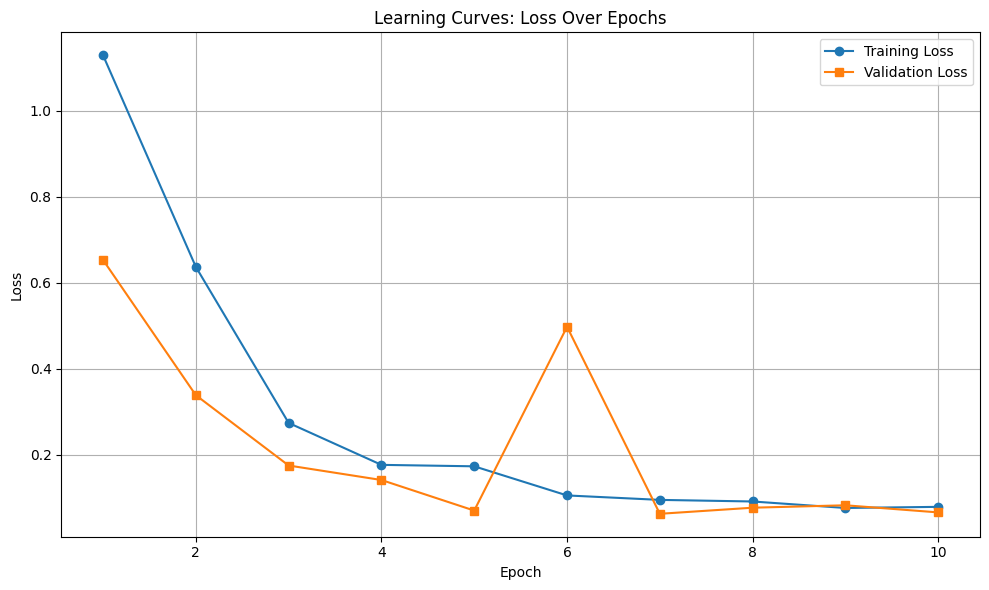

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(metrics_df):
    """
    Plots training and validation loss over epochs.

    Args:
        metrics_df (pd.DataFrame): DataFrame with 'epoch', 'train_loss', and 'val_loss'
    """
    plt.figure(figsize=(10, 6))

    # Plot training and validation loss
    plt.plot(metrics_df['epoch'], metrics_df['train_loss'], label='Training Loss', marker='o')
    plt.plot(metrics_df['epoch'], metrics_df['val_loss'], label='Validation Loss', marker='s')

    plt.title('Learning Curves: Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function
plot_learning_curves(metrics_df)


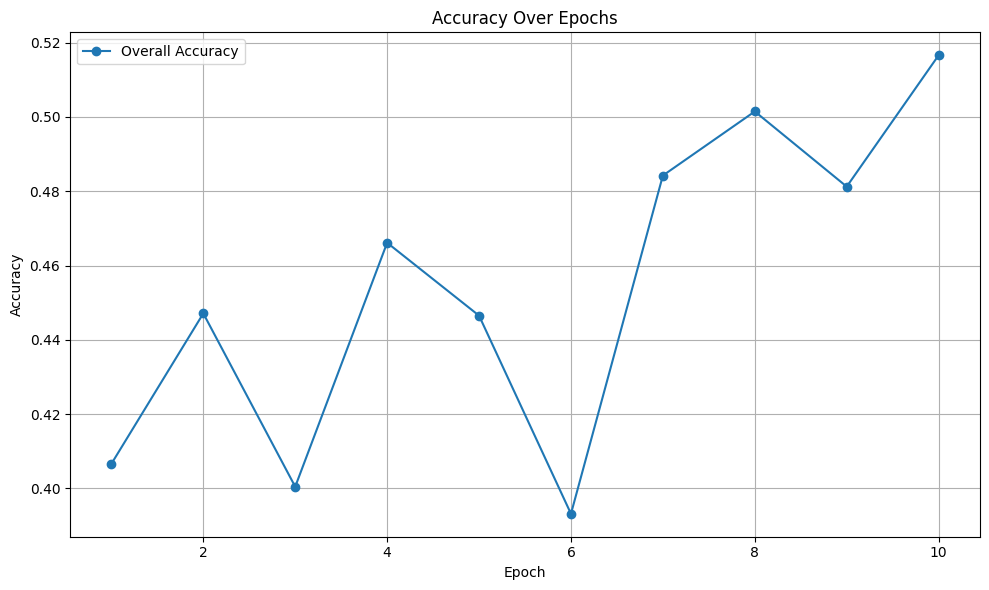

In [ ]:
def plot_accuracy_curves(metrics_df):
    """
    Plots training and validation accuracy over epochs.

    Args:
        metrics_df (pd.DataFrame): DataFrame with 'epoch', 'dice_class_0', 'dice_class_1', 'dice_class_2', 'dice_class_3'
    """
    plt.figure(figsize=(10, 6))

    # Calculate overall accuracy (average of Dice scores for all classes)
    metrics_df['overall_accuracy'] = metrics_df[['dice_class_0', 'dice_class_1', 'dice_class_2', 'dice_class_3']].mean(axis=1)

    # Plot training and validation accuracy
    plt.plot(metrics_df['epoch'], metrics_df['overall_accuracy'], label='Overall Accuracy', marker='o')

    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function
plot_accuracy_curves(metrics_df)

In [ ]:
#plt.savefig("loss_curve.png")

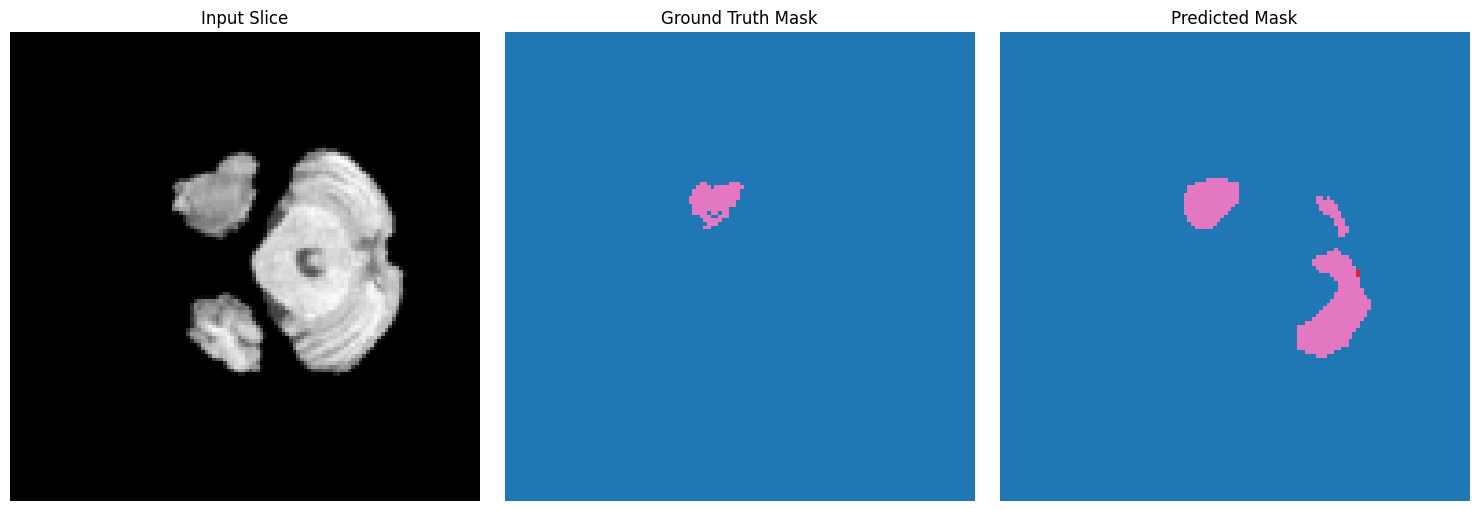

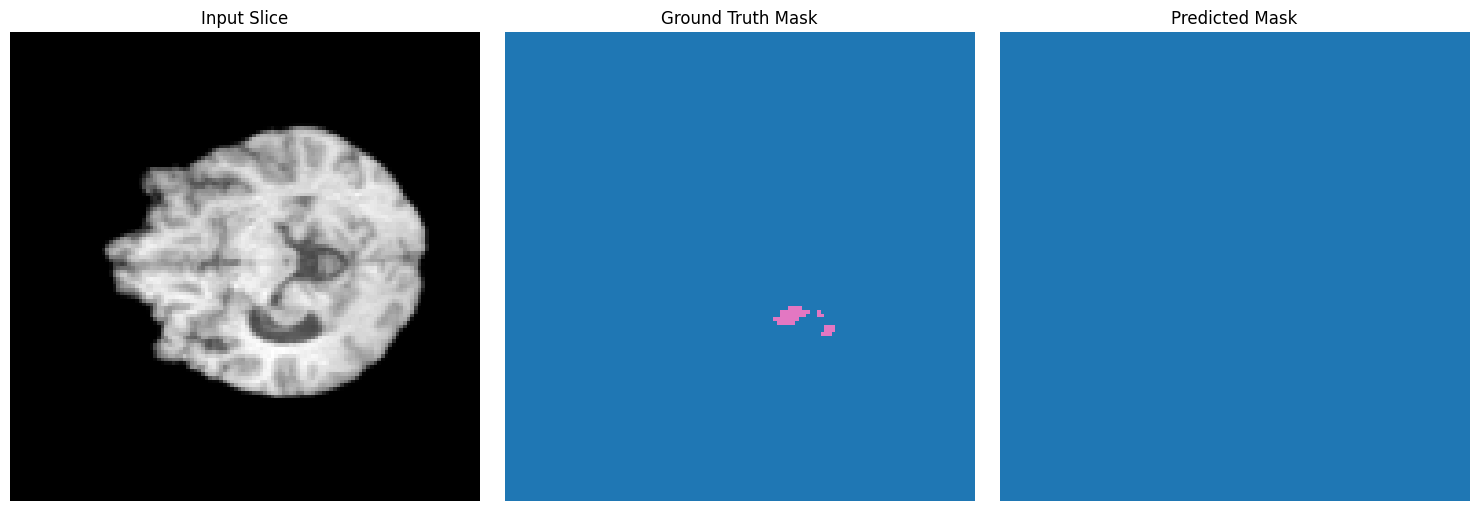

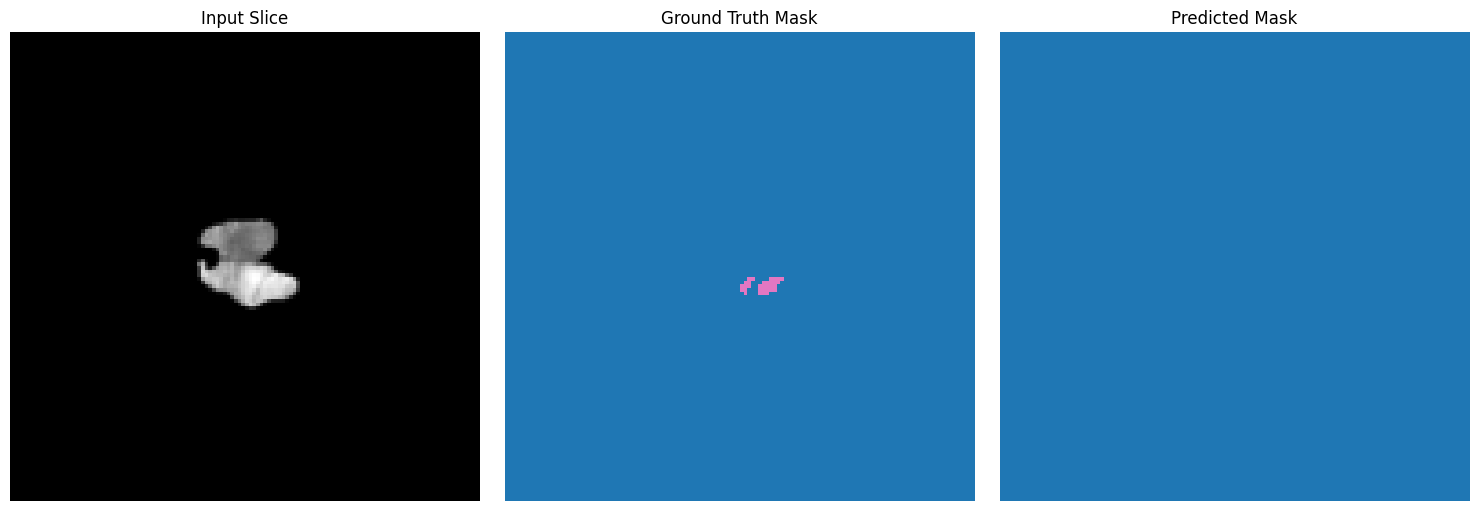

In [ ]:
def visualize_predictions(model, dataset, num_samples=3, device='cuda', class_labels=[0, 1, 2, 3]):
    """
    Visualizes input images, ground truth masks, and predicted masks for a few validation samples.

    Args:
        model (nn.Module): Trained model
        dataset (Dataset): A dataset (e.g., val_dataset)
        num_samples (int): Number of samples to visualize
        device (str): 'cuda' or 'cpu'
        class_labels (List[int]): List of valid segmentation class IDs
    """
    model.eval()
    model.to(device)

    # Choose random samples from the dataset
    sample_indices = random.sample(range(len(dataset)), num_samples)

    for idx in sample_indices:
        image, mask = dataset[idx]
        image = image.unsqueeze(0).to(device)  # Add batch dimension [1, C, H, W]
        mask = mask.cpu().numpy()

        with torch.no_grad():
            logits = model(image)  # [1, C, H, W]
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()  # [H, W]

        # Plot input, ground truth, and prediction
        plt.figure(figsize=(15, 5))

        # Input (show first channel only)
        plt.subplot(1, 3, 1)
        plt.imshow(image[0, 0].cpu(), cmap='gray')
        plt.title('Input Slice')
        plt.axis('off')

        # Ground Truth
        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='tab10', vmin=min(class_labels), vmax=max(class_labels))
        plt.title('Ground Truth Mask')
        plt.axis('off')

        # Prediction
        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='tab10', vmin=min(class_labels), vmax=max(class_labels))
        plt.title('Predicted Mask')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Show 3 random samples from the validation dataset
visualize_predictions(
    model=model,
    dataset=val_dataset,
    num_samples=3,
    device='cuda',  # or 'cpu' if no GPU
    class_labels=[0, 1, 2, 3]
)

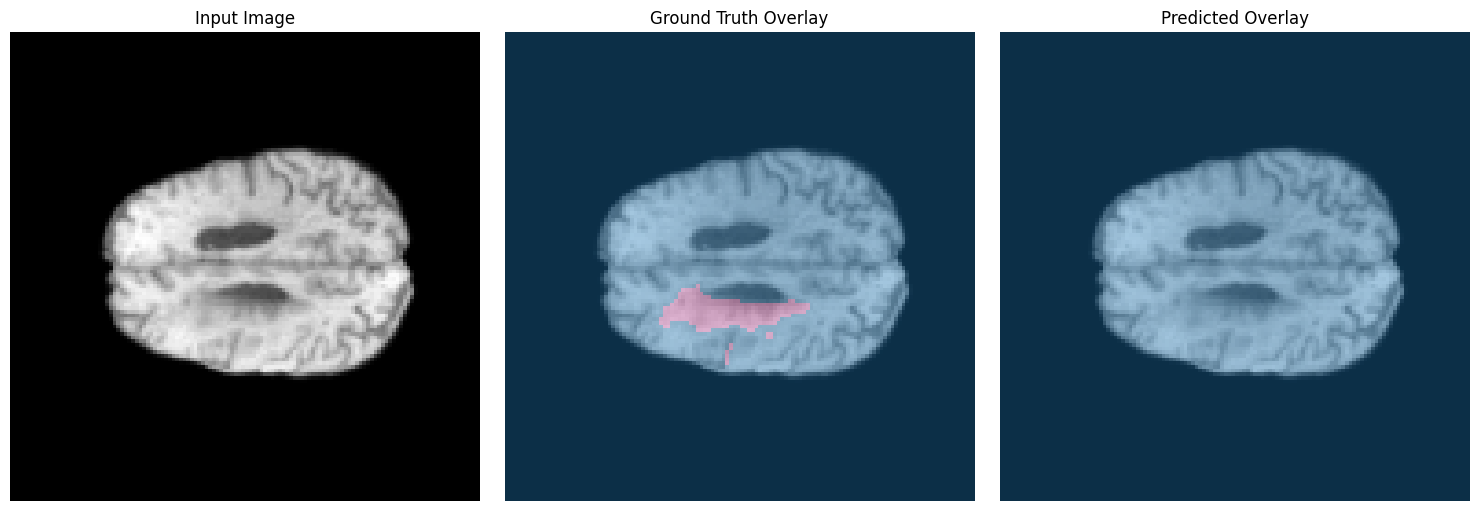

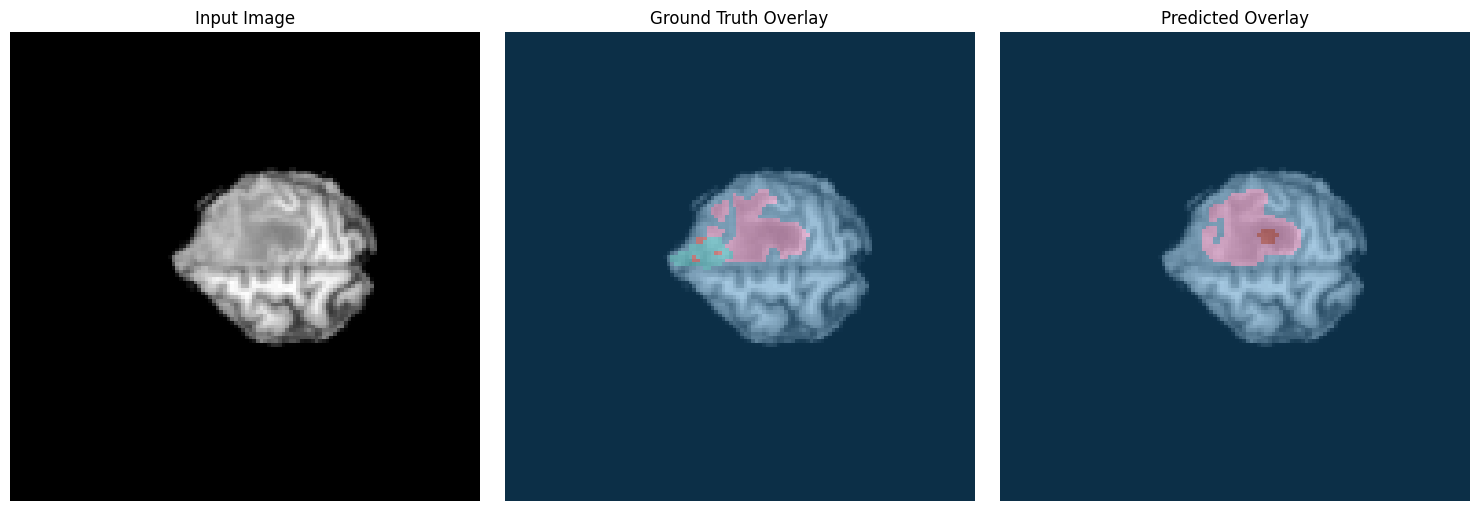

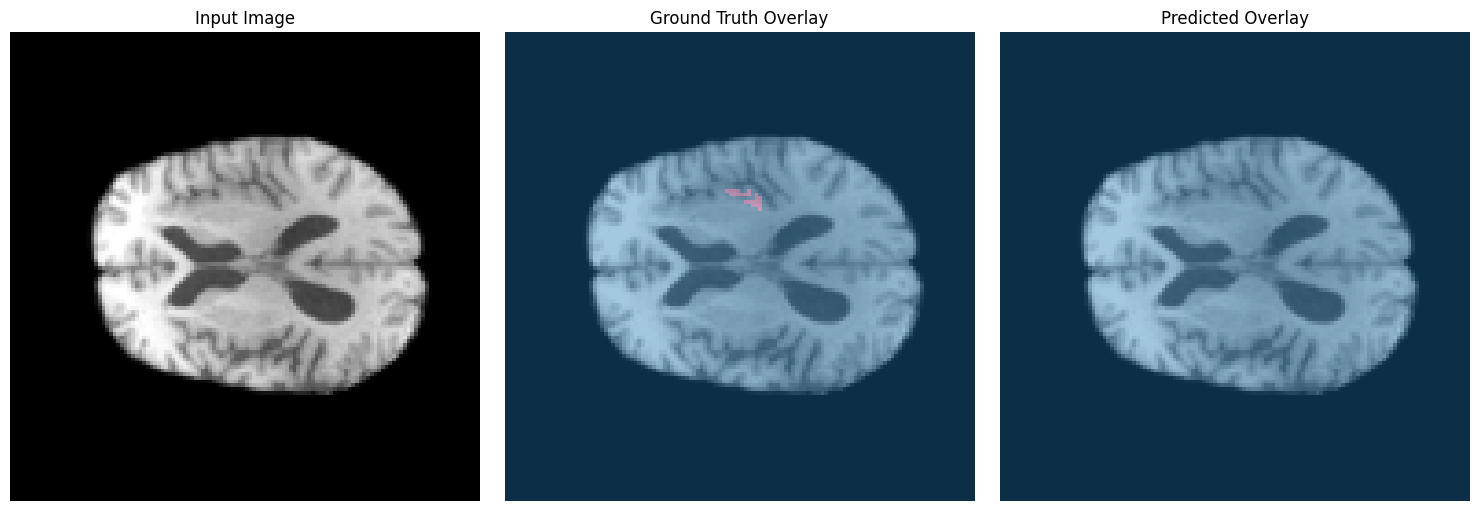

In [ ]:
def visualize_predictions_overlay(model, dataset, num_samples=3, device='cuda', class_labels=[0,1,2,3]):

    model.eval()
    model.to(device)

    sample_indices = random.sample(range(len(dataset)), num_samples)

    for idx in sample_indices:
        image, mask = dataset[idx]
        image = image.unsqueeze(0).to(device)
        mask = mask.cpu().numpy()

        with torch.no_grad():
            logits = model(image)
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        base_img = image[0, 0].cpu().numpy()
        plt.figure(figsize=(15, 5))

        # Original input
        plt.subplot(1, 3, 1)
        plt.imshow(base_img, cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        # Ground Truth with overlay
        plt.subplot(1, 3, 2)
        plt.imshow(base_img, cmap='gray')
        plt.imshow(mask, cmap='tab10', alpha=0.4, vmin=min(class_labels), vmax=max(class_labels))
        plt.title("Ground Truth Overlay")
        plt.axis("off")

        # Prediction with overlay
        plt.subplot(1, 3, 3)
        plt.imshow(base_img, cmap='gray')
        plt.imshow(pred, cmap='tab10', alpha=0.4, vmin=min(class_labels), vmax=max(class_labels))
        plt.title("Predicted Overlay")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# Show 3 random samples from the validation dataset with overlay masks
visualize_predictions_overlay(
    model=model,
    dataset=val_dataset,
    num_samples=3,
    device='cuda',
    class_labels=[0, 1, 2, 3]
)